In [9]:
# ==== Cell 1: セットアップ ====
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, AllChem, MACCSkeys
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import GroupKFold, KFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

import lightgbm as lgb

RDLogger.DisableLog("rdApp.*")
RANDOM_STATE = 42

In [10]:
# ==== Cell 2: データ読み込み・前処理（ロードマップ 2章） ====
train_df = pd.read_csv("for_M1/qm9_bandgap_train.csv")   # columns: smiles, gap_eV
test_df = pd.read_csv("for_M1/qm9_bandgap_test_without_answer.csv")  # columns: smiles


def to_mol(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    return mol


def preprocess(df, has_label):
    mols, valid_idx = [], []
    fail_count = 0
    for i, smiles in enumerate(df["smiles"]):
        mol = to_mol(smiles)
        if mol is None:
            fail_count += 1
            continue
        mols.append(mol)
        valid_idx.append(i)
    print(f"Mol生成失敗: {fail_count} / {len(df)} 件")
    out = df.iloc[valid_idx].reset_index(drop=True).copy()
    out["mol"] = mols
    return out


train_df = preprocess(train_df, has_label=True)
test_df = preprocess(test_df, has_label=False)

# 重複分子の除去
train_df["canonical_smiles"] = train_df["mol"].apply(Chem.MolToSmiles)
n_before = len(train_df)
train_df = train_df.drop_duplicates(subset="canonical_smiles").reset_index(drop=True)
print(f"重複除去: {n_before - len(train_df)} 件")

Mol生成失敗: 0 / 15000 件
Mol生成失敗: 0 / 4000 件
重複除去: 2 件


In [11]:
# ==== Cell 3: 特徴量生成関数（ロードマップ 3章） ====
descriptor_names = [name for name, _ in Descriptors._descList]
descriptor_calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)


def calc_descriptors(mols):
    rows = []
    for mol in mols:
        vals = descriptor_calc.CalcDescriptors(mol)
        rows.append(vals)
    df = pd.DataFrame(rows, columns=descriptor_names)
    df = df.replace([np.inf, -np.inf], np.nan)
    return df


def calc_morgan(mols, radius=2, n_bits=2048):
    arr = np.zeros((len(mols), n_bits), dtype=np.int8)
    for i, mol in enumerate(mols):
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
        for bit in fp.GetOnBits():
            arr[i, bit] = 1
    cols = [f"morgan_{i}" for i in range(n_bits)]
    return pd.DataFrame(arr, columns=cols)


def calc_maccs(mols):
    arr = np.zeros((len(mols), 167), dtype=np.int8)
    for i, mol in enumerate(mols):
        fp = MACCSkeys.GenMACCSKeys(mol)
        for bit in fp.GetOnBits():
            arr[i, bit] = 1
    cols = [f"maccs_{i}" for i in range(167)]
    return pd.DataFrame(arr, columns=cols)

In [12]:
# ==== Cell 4: 特徴量テーブル構築（train / test 共通） ====
def build_feature_table(df):
    mols = df["mol"].tolist()
    desc = calc_descriptors(mols)
    morgan = calc_morgan(mols)
    maccs = calc_maccs(mols)
    return desc, morgan, maccs


train_desc, train_morgan, train_maccs = build_feature_table(train_df)
test_desc, test_morgan, test_maccs = build_feature_table(test_df)

# 記述子の欠損は中央値で補完（testはtrainの中央値を使う）
desc_median = train_desc.median()
train_desc = train_desc.fillna(desc_median)
test_desc = test_desc.fillna(desc_median)

In [13]:
# ==== Cell 5: 特徴量選択・結合（ロードマップ 4章） ====
def variance_filter(train_mat, test_mat, threshold=0.0):
    vt = VarianceThreshold(threshold=threshold)
    vt.fit(train_mat)
    return train_mat.loc[:, vt.get_support()], test_mat.loc[:, vt.get_support()]


train_morgan_f, test_morgan_f = variance_filter(train_morgan, test_morgan)
train_maccs_f, test_maccs_f = variance_filter(train_maccs, test_maccs)

# 記述子は連続値なのでスケーリング
scaler = StandardScaler()
train_desc_scaled = pd.DataFrame(
    scaler.fit_transform(train_desc), columns=train_desc.columns
)
test_desc_scaled = pd.DataFrame(
    scaler.transform(test_desc), columns=test_desc.columns
)

# 単純結合（記述子 + Morgan + MACCS）
X_train = pd.concat([train_desc_scaled, train_morgan_f, train_maccs_f], axis=1)
X_test = pd.concat([test_desc_scaled, test_morgan_f, test_maccs_f], axis=1)
y_train = train_df["gap_eV"].values

print(f"結合後の特徴量数: {X_train.shape[1]}")

結合後の特徴量数: 2387


In [14]:
# ==== Cell 5.5: 相関フィルタ + Morganの次元圧縮 ====
from sklearn.decomposition import TruncatedSVD


def correlation_filter(train_mat, test_mat, threshold=0.95):
    corr = train_mat.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop_cols = [col for col in upper.columns if any(upper[col] > threshold)]
    print(f"相関フィルタで除去: {len(drop_cols)} / {train_mat.shape[1]} 列")
    return train_mat.drop(columns=drop_cols), test_mat.drop(columns=drop_cols)


# 記述子は相関が高いものが多いので、ここに適用
train_desc_f, test_desc_f = correlation_filter(train_desc_scaled, test_desc_scaled)

# Morganは疎で高次元なので相関フィルタよりSVDで圧縮する方が現実的
N_SVD_COMPONENTS = 128
svd = TruncatedSVD(n_components=N_SVD_COMPONENTS, random_state=RANDOM_STATE)
train_morgan_svd = pd.DataFrame(
    svd.fit_transform(train_morgan_f),
    columns=[f"morgan_svd_{i}" for i in range(N_SVD_COMPONENTS)],
)
test_morgan_svd = pd.DataFrame(
    svd.transform(test_morgan_f),
    columns=[f"morgan_svd_{i}" for i in range(N_SVD_COMPONENTS)],
)
print(f"Morgan圧縮後の累積寄与率: {svd.explained_variance_ratio_.sum():.3f}")

# 圧縮版の結合特徴量（元のX_train/X_testとは別に用意し、後で比較する）
X_train_engineered = pd.concat([train_desc_f, train_morgan_svd, train_maccs_f], axis=1)
X_test_engineered = pd.concat([test_desc_f, test_morgan_svd, test_maccs_f], axis=1)

print(f"単純結合: {X_train.shape[1]} 列 → エンジニアリング後: {X_train_engineered.shape[1]} 列")

相関フィルタで除去: 25 / 217 列
Morgan圧縮後の累積寄与率: 0.538
単純結合: 2387 列 → エンジニアリング後: 442 列


In [15]:
# ==== Cell 6: スキャフォールド分割によるグループ定義（ロードマップ 5章） ====
def get_scaffold(mol):
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)


train_df["scaffold"] = train_df["mol"].apply(get_scaffold)
scaffold_groups = train_df["scaffold"].values

In [16]:
# ==== Cell 7: 特徴量単体 vs 結合のベースライン比較（ロードマップ 4章） ====
def cv_mae(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    maes = []
    for train_idx, valid_idx in gkf.split(X, y, groups):
        model = lgb.LGBMRegressor(
            n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE
        )
        model.fit(X.iloc[train_idx], y[train_idx])
        pred = model.predict(X.iloc[valid_idx])
        maes.append(mean_absolute_error(y[valid_idx], pred))
    return np.mean(maes)


baseline_results = {
    "descriptors_only": cv_mae(train_desc_scaled, y_train, scaffold_groups),
    "morgan_only": cv_mae(train_morgan_f, y_train, scaffold_groups),
    "maccs_only": cv_mae(train_maccs_f, y_train, scaffold_groups),
    "combined": cv_mae(X_train, y_train, scaffold_groups),
}
for name, mae in baseline_results.items():
    print(f"{name:16s}: MAE = {mae:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004695 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19189
[LightGBM] [Info] Number of data points in the train set: 11998, number of used features: 177
[LightGBM] [Info] Start training from score 6.841033
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19354
[LightGBM] [Info] Number of data points in the train set: 11998, number of used features: 178
[LightGBM] [Info] Start training from score 6.794075
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004321 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Tota

In [17]:
# ==== Cell 8: モデル比較（発熱を抑えた版） ====
import os
import time

# ライブラリが内部で使うスレッド数を制限（コア全部を使わせない）
N_THREADS = 2  # お使いのPCのコア数に応じて 2〜4 程度に調整
os.environ["OMP_NUM_THREADS"] = str(N_THREADS)
os.environ["MKL_NUM_THREADS"] = str(N_THREADS)
os.environ["OPENBLAS_NUM_THREADS"] = str(N_THREADS)

COOLDOWN_SEC = 15  # 1foldごとの休憩時間。長いほどPCに優しいが遅くなる


def cv_mae_model(model_fn, X, y, groups, n_splits=5, cooldown=COOLDOWN_SEC):
    gkf = GroupKFold(n_splits=n_splits)
    maes = []
    for fold_i, (train_idx, valid_idx) in enumerate(gkf.split(X, y, groups), start=1):
        model = model_fn()
        model.fit(X.iloc[train_idx], y[train_idx])
        pred = model.predict(X.iloc[valid_idx])
        mae = mean_absolute_error(y[valid_idx], pred)
        maes.append(mae)
        print(f"  fold {fold_i}/{n_splits} MAE = {mae:.4f}")

        if cooldown > 0:
            time.sleep(cooldown)  # CPUを休ませて熱を逃がす
    return np.mean(maes)


model_candidates = {
    "LightGBM": lambda: lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        n_jobs=N_THREADS,
    ),
    "RandomForest": lambda: RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=N_THREADS,
    ),
    "ElasticNet": lambda: ElasticNet(
        alpha=0.01, l1_ratio=0.5, random_state=RANDOM_STATE
    ),
}

results = {}
for name, model_fn in model_candidates.items():
    print(f"=== {name} ===")
    mae = cv_mae_model(model_fn, X_train, y_train, scaffold_groups)
    results[name] = mae
    print(f"{name:14s}: 平均MAE = {mae:.4f}")
    print(f"--- モデル間の休憩 {COOLDOWN_SEC * 2}秒 ---")
    time.sleep(COOLDOWN_SEC * 2)  # モデル切り替え時もさらに長めに休憩

=== LightGBM ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23361
[LightGBM] [Info] Number of data points in the train set: 11998, number of used features: 2263
[LightGBM] [Info] Start training from score 6.841033
  fold 1/5 MAE = 0.2602
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23526
[LightGBM] [Info] Number of data points in the train set: 11998, number of used features: 2264
[LightGBM] [Info] Start training from score 6.794075
  fold 2/5 MAE = 0.2410
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060727 seconds.
You can set `

In [18]:
# ==== Cell 5.6: 単純結合 vs エンジニアリング版の比較 ====
mae_simple = cv_mae_model(
    lambda: lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=N_THREADS),
    X_train, y_train, scaffold_groups,
)
mae_engineered = cv_mae_model(
    lambda: lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=N_THREADS),
    X_train_engineered, y_train, scaffold_groups,
)
print(f"単純結合        : MAE = {mae_simple:.4f}")
print(f"エンジニアリング版: MAE = {mae_engineered:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061051 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23361
[LightGBM] [Info] Number of data points in the train set: 11998, number of used features: 2263
[LightGBM] [Info] Start training from score 6.841033
  fold 1/5 MAE = 0.2602
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23526
[LightGBM] [Info] Number of data points in the train set: 11998, number of used features: 2264
[LightGBM] [Info] Start training from score 6.794075
  fold 2/5 MAE = 0.2410
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.060291 seconds.
You can set `force_row_wise=tr

In [19]:
# ==== Cell 9: Optunaによるハイパーパラメータ探索（発熱を抑えた版） ====
import optuna
import time

TRIAL_COOLDOWN_SEC = 20  # trialごとの休憩


def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),  # 上限を1500→800に抑制
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),  # 上限を127→63に抑制
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": RANDOM_STATE,
        "n_jobs": N_THREADS,  # Cell 8で定義したスレッド数制限を明示的に適用
    }
    mae = cv_mae_model(
        lambda: lgb.LGBMRegressor(**params),
        X_train, y_train, scaffold_groups,
        n_splits=3,
        cooldown=COOLDOWN_SEC,
    )
    time.sleep(TRIAL_COOLDOWN_SEC)  # trial間でもCPUを休ませる
    return mae


study = optuna.create_study(direction="minimize")
study.optimize(
    objective,
    n_trials=15,   # 30→15に削減（まず粗く探索し、必要なら追加trialを走らせる）
    n_jobs=1,      # trialを並列実行しない（複数trial同時実行が一番発熱しやすい）
)
print("Best MAE:", study.best_value)
print("Best params:", study.best_params)

/Users/ta-eito/Desktop/organic_chemistry/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-22 04:53:14,726] A new study created in memory with name: no-name-4445437f-3466-4de1-ae2c-582fb31877fb


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22890
[LightGBM] [Info] Number of data points in the train set: 9998, number of used features: 2155
[LightGBM] [Info] Start training from score 6.850345
  fold 1/3 MAE = 0.2651
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.051139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23006
[LightGBM] [Info] Number of data points in the train set: 9999, number of used features: 2158
[LightGBM] [Info] Start training from score 6.782833
  fold 2/3 MAE = 0.2351
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048944 seconds.
You can set `force_row_wise=true

[I 2026-07-22 04:54:41,126] Trial 0 finished with value: 0.24648569373720308 and parameters: {'n_estimators': 667, 'learning_rate': 0.025608885663175346, 'num_leaves': 61, 'reg_alpha': 0.0013506793259403006, 'reg_lambda': 1.2700443457635064, 'subsample': 0.6278262437780326, 'colsample_bytree': 0.8273511295062287}. Best is trial 0 with value: 0.24648569373720308.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22890
[LightGBM] [Info] Number of data points in the train set: 9998, number of used features: 2155
[LightGBM] [Info] Start training from score 6.850345
  fold 1/3 MAE = 0.2634
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23006
[LightGBM] [Info] Number of data points in the train set: 9999, number of used features: 2158
[LightGBM] [Info] Start training from score 6.782833
  fold 2/3 MAE = 0.2406
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048244 seconds.
You can set `force_row_wise=true

[I 2026-07-22 04:55:56,419] Trial 1 finished with value: 0.25072104803649664 and parameters: {'n_estimators': 467, 'learning_rate': 0.03094296285185107, 'num_leaves': 37, 'reg_alpha': 0.0019602931571389795, 'reg_lambda': 0.00237753710330025, 'subsample': 0.7976363161982785, 'colsample_bytree': 0.6849294535140771}. Best is trial 0 with value: 0.24648569373720308.


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22890
[LightGBM] [Info] Number of data points in the train set: 9998, number of used features: 2155
[LightGBM] [Info] Start training from score 6.850345
  fold 1/3 MAE = 0.2602
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049375 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23006
[LightGBM] [Info] Number of data points in the train set: 9999, number of used features: 2158
[LightGBM] [Info] Start training from score 6.782833
  fold 2/3 MAE = 0.2345
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048471 seconds.
You can set `force_row_wise=true

[I 2026-07-22 05:11:36,959] Trial 13 finished with value: 0.24476773947322827 and parameters: {'n_estimators': 584, 'learning_rate': 0.09745800001089987, 'num_leaves': 55, 'reg_alpha': 0.0010233197304687406, 'reg_lambda': 3.0968916163945206, 'subsample': 0.7111559913044843, 'colsample_bytree': 0.6074341754445441}. Best is trial 11 with value: 0.24268170863875368.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 22890
[LightGBM] [Info] Number of data points in the train set: 9998, number of used features: 2155
[LightGBM] [Info] Start training from score 6.850345
  fold 1/3 MAE = 0.2572
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.050226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23006
[LightGBM] [Info] Number of data points in the train set: 9999, number of used features: 2158
[LightGBM] [Info] Start training from score 6.782833
  fold 2/3 MAE = 0.2362
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049415 seconds.
You can set `force_row_wise=true

[I 2026-07-22 05:12:57,621] Trial 14 finished with value: 0.24392510769500664 and parameters: {'n_estimators': 579, 'learning_rate': 0.06732215228704214, 'num_leaves': 55, 'reg_alpha': 0.004867039076824048, 'reg_lambda': 9.824441713667063, 'subsample': 0.8231782977030547, 'colsample_bytree': 0.6456251980420595}. Best is trial 11 with value: 0.24268170863875368.


Best MAE: 0.24268170863875368
Best params: {'n_estimators': 619, 'learning_rate': 0.09252901297773805, 'num_leaves': 61, 'reg_alpha': 0.0018681259739536694, 'reg_lambda': 8.049865519222362, 'subsample': 0.7290105342974004, 'colsample_bytree': 0.6123316975149912}


In [22]:
# ==== Cell 10: 最終モデル学習 & submission.csv 作成（ロードマップ 5, 10章） ====
best_params = study.best_params
best_params["random_state"] = RANDOM_STATE

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(X_train, y_train)

test_pred = final_model.predict(X_test)

submission = pd.DataFrame({
    "smiles": test_df["smiles"].values,
    "gap_eV": test_pred,
})
submission.to_csv("for_M1/submission.csv", index=False)
print("submission.csv を作成しました")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.081685 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23998
[LightGBM] [Info] Number of data points in the train set: 14998, number of used features: 2331
[LightGBM] [Info] Start training from score 6.824113
submission.csv を作成しました


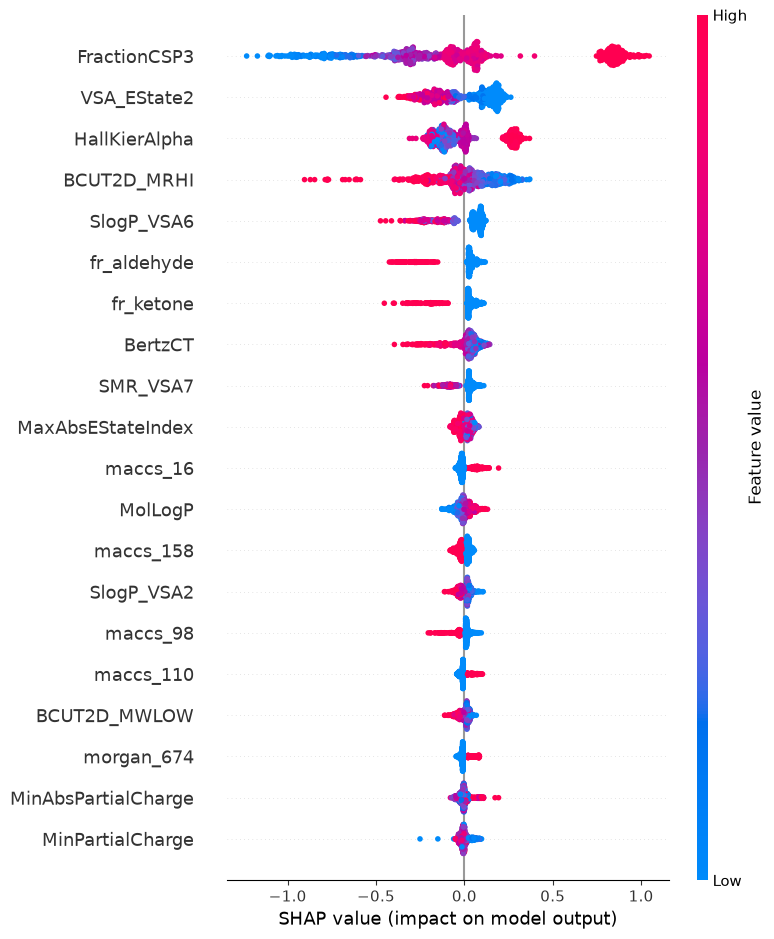

In [23]:
# ==== Cell 11 (任意): SHAPによる解釈性分析（ロードマップ 9章） ====
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train.sample(1000, random_state=RANDOM_STATE))
shap.summary_plot(shap_values, X_train.sample(1000, random_state=RANDOM_STATE))

In [24]:
# ==== Cell 12: スタッキング（ロードマップ4章の最終手段） ====
from sklearn.linear_model import Ridge

def get_oof_predictions(model_fn, X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    oof = np.zeros(len(y))
    for train_idx, valid_idx in gkf.split(X, y, groups):
        model = model_fn()
        model.fit(X.iloc[train_idx], y[train_idx])
        oof[valid_idx] = model.predict(X.iloc[valid_idx])
        time.sleep(COOLDOWN_SEC)
    return oof


# 特徴量ごとに個別モデルのout-of-fold予測を作る
oof_desc = get_oof_predictions(
    lambda: lgb.LGBMRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=N_THREADS),
    train_desc_f, y_train, scaffold_groups,
)
oof_morgan = get_oof_predictions(
    lambda: lgb.LGBMRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=N_THREADS),
    train_morgan_svd, y_train, scaffold_groups,
)
oof_maccs = get_oof_predictions(
    lambda: lgb.LGBMRegressor(n_estimators=500, random_state=RANDOM_STATE, n_jobs=N_THREADS),
    train_maccs_f, y_train, scaffold_groups,
)

# メタモデル（Ridge）でOOF予測を統合
meta_X = np.column_stack([oof_desc, oof_morgan, oof_maccs])
meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_X, y_train)
stacking_pred = meta_model.predict(meta_X)
mae_stacking = mean_absolute_error(y_train, stacking_pred)
print(f"スタッキング（学習データ内MAE参考値）: {mae_stacking:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003037 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16159
[LightGBM] [Info] Number of data points in the train set: 11998, number of used features: 154
[LightGBM] [Info] Start training from score 6.841033
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003216 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 16308
[LightGBM] [Info] Number of data points in the train set: 11998, number of used features: 155
[LightGBM] [Info] Start training from score 6.794075
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003208 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not e

KeyboardInterrupt: 

In [ ]:
import sys
print(sys.executable)

/Users/ta-eito/Desktop/organic_chemistry/.venv/bin/python
